# **1. Import Library**
Pada tahap ini, Tim AI melakukan import beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [139]:
# Library dasar
import pandas as pd
import numpy as np
import datetime

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report

# Deep Learning - TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# **2. Memuat Dataset dari tim Data Science**
Memuat dataset yang telah di proses oleh tim data science

In [140]:
### MULAI CODE ###

df = pd.read_csv("dataset_stunting_clean.csv")

### SELESAI CODE ###

In [141]:
# Tampilkan 5 baris pertama dengan function head

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,id_anak,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_bb_u,zscore_bb_u,status_tb_u,zscore_tb_u,status_bb_tb,zscore_bb_tb
0,No.,NaN,NaN,Weight,Height,Weight for Age,Z-Score W/A,Height for Age,Z-Score H/A,Weight for Height,Z-Score W/H
1,1,Perempuan,54.0,13.2,97.5,Normal,-1.94,Stunting,-2.11,Normal,-0.95
2,2,Laki-laki,44.0,12,92,Normal,-1.92,Stunting,-2.22,Normal,-0.88
3,3,Laki-laki,57.0,14,97,Normal,-1.9,Stunting,-2.58,Normal,-0.48
4,4,Laki-laki,26.0,11,79,Normal,-1.15,Stunting,-3.11,Normal,0.68


## **Pembersihan Tingkat Awal Dataset**

### Melakukan perbaikan dalam dataset (terdapat double header yang terbaca sebagai baris pertama dalam dataset)

In [142]:
# Menghapus baris pertama dalam dataset yang terdeteksi sebagai double header

### MULAI CODE ###

df = df[df['id_anak'] != 'No.'].reset_index(drop=True)

### SELESAIN CODE ###

In [143]:
# Tampilkan 5 baris pertama dengan function head

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,id_anak,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_bb_u,zscore_bb_u,status_tb_u,zscore_tb_u,status_bb_tb,zscore_bb_tb
0,1,Perempuan,54.0,13.2,97.5,Normal,-1.94,Stunting,-2.11,Normal,-0.95
1,2,Laki-laki,44.0,12,92,Normal,-1.92,Stunting,-2.22,Normal,-0.88
2,3,Laki-laki,57.0,14,97,Normal,-1.9,Stunting,-2.58,Normal,-0.48
3,4,Laki-laki,26.0,11,79,Normal,-1.15,Stunting,-3.11,Normal,0.68
4,5,Perempuan,59.0,14.6,98,Normal,-1.66,Stunting,-2.49,Normal,-0.18


In [144]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40071 entries, 0 to 40070
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_anak        40071 non-null  object 
 1   jenis_kelamin  40071 non-null  object 
 2   usia_bulan     40069 non-null  float64
 3   berat_badan    40071 non-null  object 
 4   tinggi_badan   40071 non-null  object 
 5   status_bb_u    40071 non-null  object 
 6   zscore_bb_u    40071 non-null  object 
 7   status_tb_u    40071 non-null  object 
 8   zscore_tb_u    40071 non-null  object 
 9   status_bb_tb   40066 non-null  object 
 10  zscore_bb_tb   40071 non-null  object 
dtypes: float64(1), object(10)
memory usage: 3.4+ MB


In [145]:
# Mengubah beberapa kolom dari tipe data object (teks) menjadi numerik (angka)
# Hal ini diperlukan karena sebelumnya terdapat data tidak valid (seperti teks/header ganda)
# yang menyebabkan kolom angka terbaca sebagai object

### MULAI CODE ###

cols = ['berat_badan', 'tinggi_badan', 'zscore_bb_u', 'zscore_tb_u', 'zscore_bb_tb']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### SELESAI CODE ###

In [146]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40071 entries, 0 to 40070
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_anak        40071 non-null  object 
 1   jenis_kelamin  40071 non-null  object 
 2   usia_bulan     40069 non-null  float64
 3   berat_badan    40071 non-null  float64
 4   tinggi_badan   40071 non-null  float64
 5   status_bb_u    40071 non-null  object 
 6   zscore_bb_u    40071 non-null  float64
 7   status_tb_u    40071 non-null  object 
 8   zscore_tb_u    40071 non-null  float64
 9   status_bb_tb   40066 non-null  object 
 10  zscore_bb_tb   40071 non-null  float64
dtypes: float64(6), object(5)
memory usage: 3.4+ MB


In [147]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe()

### SELESAI CODE ###

,usia_bulan,berat_badan,tinggi_badan,zscore_bb_u,zscore_tb_u,zscore_bb_tb
count,40069.000000,40071.000000,40071.000000,40071.000000,40071.000000,40071.000000
mean,33.020664,11.661496,86.051172,-0.931832,-1.735896,0.208438
std,15.823079,29.507224,11.816466,44.467158,1.185741,75.212821
min,0.000000,2.000000,44.000000,-5.800000,-10.970000,-6.400000
25%,20.000000,9.500000,78.000000,-1.920000,-2.460000,-1.200000
50%,34.000000,11.500000,87.300000,-1.340000,-1.800000,-0.610000
75%,47.000000,13.400000,95.200000,-0.800000,-1.040000,0.020000
max,60.000000,3100.000000,120.000000,4622.490000,6.600000,7657.390000


## Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA)

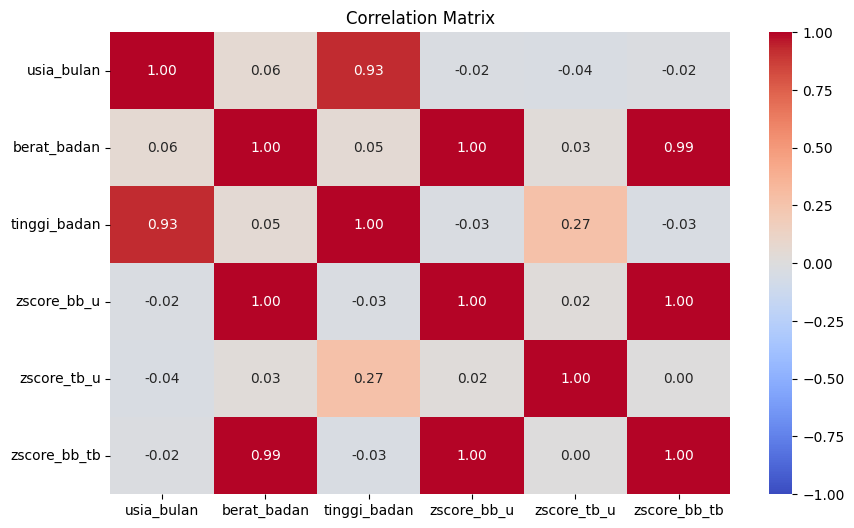

In [148]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

### MULAI CODE ###

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

### SELESAI CODE ###

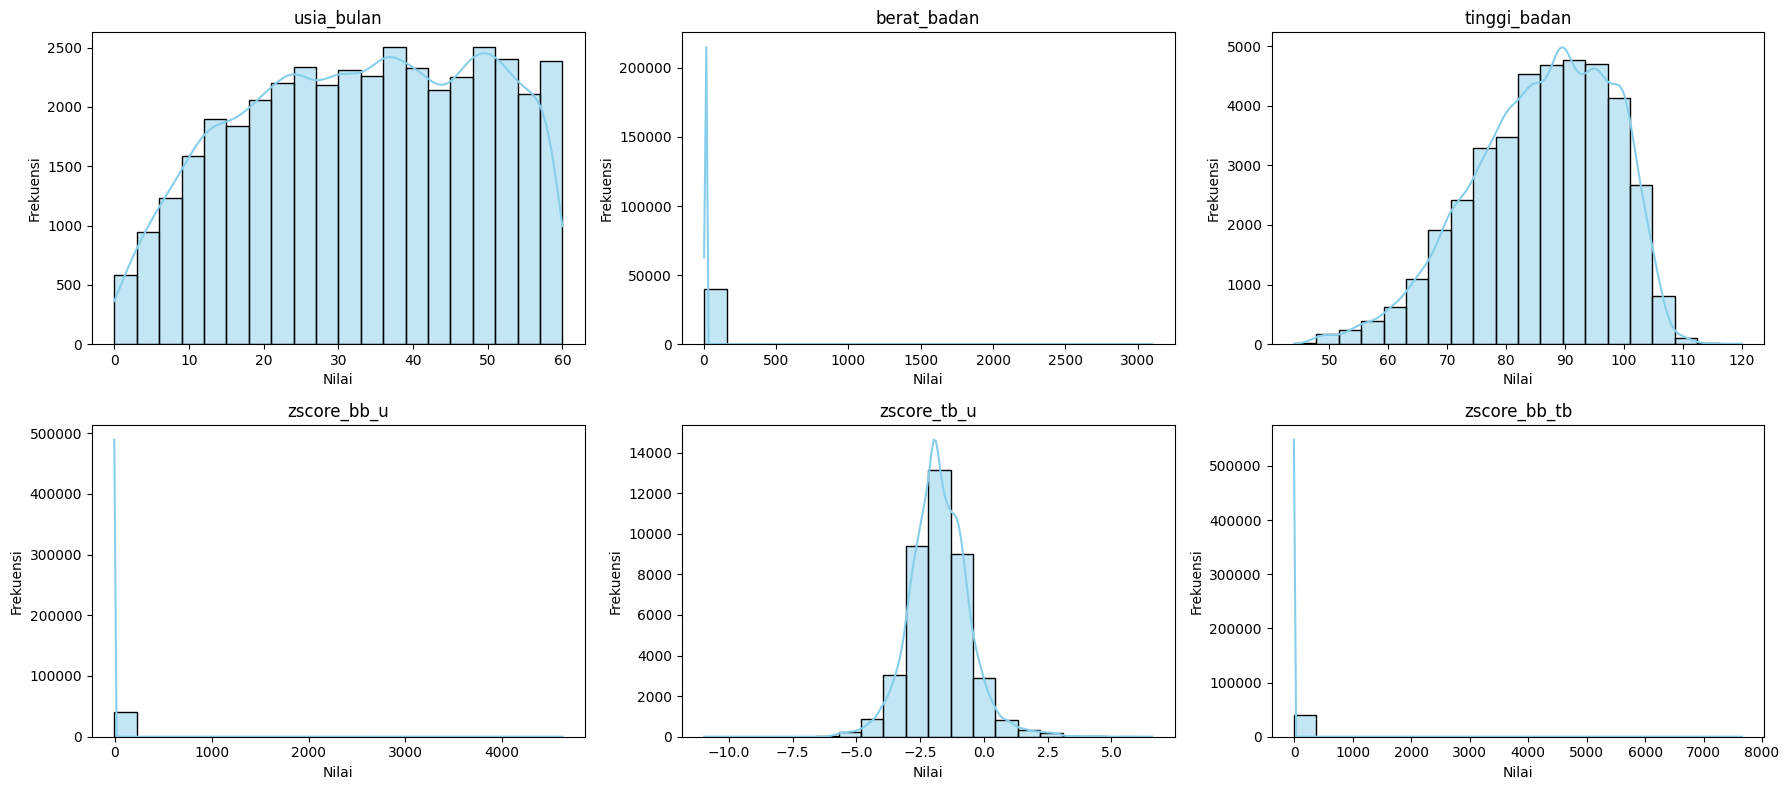

In [149]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, tim AI akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang kami lakukan dalam tahapan ini diantaranya:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan drop pada data yyang terdapat null/nan dan data yang duplicate
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.


In [150]:
# Mengecek dataset menggunakan isnull().sum()

### MULAI CODE ###

df.isnull().sum()

### SELESAI CODE ###

,0
id_anak,0
jenis_kelamin,0
usia_bulan,2
berat_badan,0
tinggi_badan,0
status_bb_u,0
zscore_bb_u,0
status_tb_u,0
zscore_tb_u,0
status_bb_tb,5


In [151]:
# Mengecek dataset menggunakan duplicated().sum()

### MULAI CODE ###

df.duplicated().sum()

### SELESAI CODE ###

np.int64(0)

In [152]:
# Menangani data yang hilang.

### MULAI CODE ###

# Memanggil fungsi untuk menghapus baris yang hilang
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()

### SELESAI CODE ###

,0
id_anak,0
jenis_kelamin,0
usia_bulan,0
berat_badan,0
tinggi_badan,0
status_bb_u,0
zscore_bb_u,0
status_tb_u,0
zscore_tb_u,0
status_bb_tb,0


In [153]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

### MULAI CODE ###

# Buat list comprehension untuk memfilter nama kolom.
#    - Iterasi melalui semua nama kolom (col).
#    - Menggunakan .lower() untuk membuat perbandingan case-insensitive (mengabaikan besar/kecil).

cols_to_drop = [col for col in df.columns if
                'id_anak' in col.lower() or
                'status_bb_u' in col.lower() or
                'zscore_bb_u' in col.lower() or
                'zscore_tb_u' in col.lower() or
                'status_bb_tb' in col.lower() or
                'zscore_bb_tb' in col.lower() ]

# Menggunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

### SELESAI CODE ###

,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_tb_u
0,Perempuan,54.0,13.2,97.5,Stunting
1,Laki-laki,44.0,12.0,92.0,Stunting
2,Laki-laki,57.0,14.0,97.0,Stunting
3,Laki-laki,26.0,11.0,79.0,Stunting
4,Perempuan,59.0,14.6,98.0,Stunting


In [154]:
# Melakukan feuture encoding untuk fitur kategorikal

### MULAI CODE ###

categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}


for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder


df.head()

### SELESAI CODE ###

,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_tb_u
0,1,54.0,13.2,97.5,0
1,0,44.0,12.0,92.0,0
2,0,57.0,14.0,97.0,0
3,0,26.0,11.0,79.0,0
4,1,59.0,14.6,98.0,0


In [155]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.

### MULAI CODE ###

df.columns.tolist()

### SELESAI CODE ###

['jenis_kelamin', 'usia_bulan', 'berat_badan', 'tinggi_badan', 'status_tb_u']

Ringkasan Outlier
           Fitur  Lower Bound  Upper Bound  Jumlah Outlier Persentase
0  jenis_kelamin        -1.50         2.50               0      0.00%
1     usia_bulan       -20.50        87.50               0      0.00%
2    berat_badan         3.65        19.25             192      0.48%
3   tinggi_badan        52.20       121.00             216      0.54%
4    status_tb_u        -1.50         2.50               0      0.00%


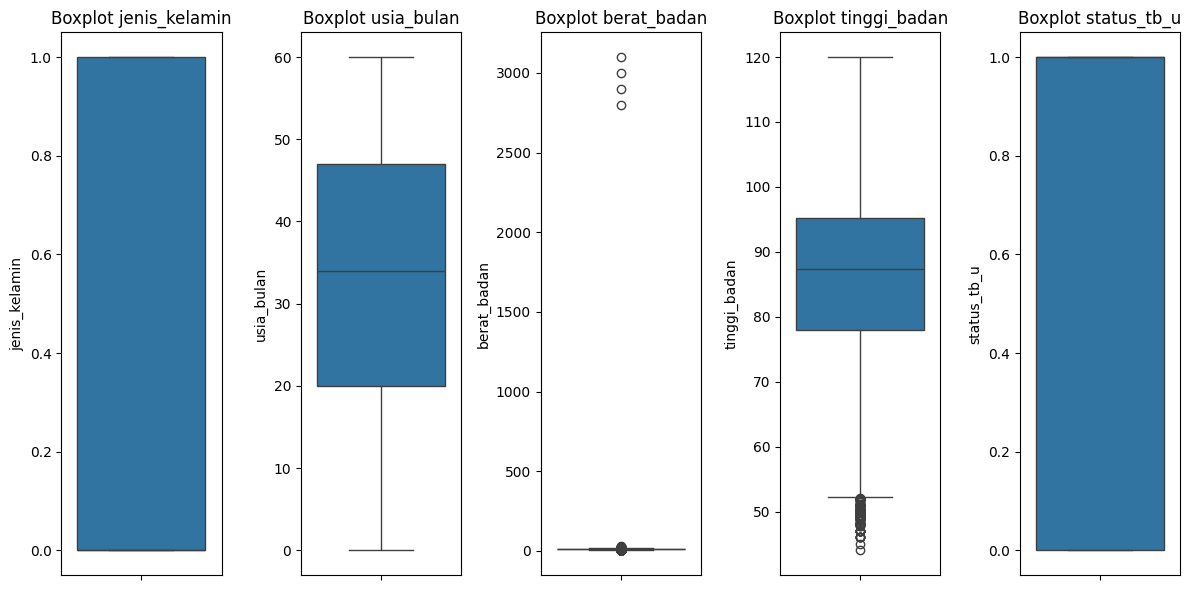

In [156]:
# Melakukan pengecekan outliner pada dataset

### MULAI CODE ###

def check_outliers(df, numerical_cols):
    # 1. Menghitung jumlah outlier secara statistik
    outlier_summary = []

    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Hitung jumlah baris yang berada di luar batas
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary.append({
            'Fitur': col,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Jumlah Outlier': len(outliers),
            'Persentase': f"{(len(outliers) / len(df)) * 100:.2f}%"
        })

    # Tampilkan tabel ringkasan
    summary_df = pd.DataFrame(outlier_summary)
    print("Ringkasan Outlier")
    print(summary_df)

    # 2. Visualisasi dengan Boxplot
    plt.figure(figsize=(12, 6))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(1, len(numerical_cols), i)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()

numerical_features = ['jenis_kelamin', 'usia_bulan', 'berat_badan', 'tinggi_badan', 'status_tb_u']
check_outliers(df, numerical_features)

In [157]:
### MULAI CODE ###

# Fitur (input model)
X = df[['jenis_kelamin', 'usia_bulan', 'berat_badan', 'tinggi_badan']]

# Label/target (yang diprediksi)
y = df['status_tb_u']

print("Fitur (X):", X.columns.tolist())
print("Label (y):", y.name)

### SELESAI CODE ###

Fitur (X): ['jenis_kelamin', 'usia_bulan', 'berat_badan', 'tinggi_badan']
Label (y): status_tb_u


In [158]:
# Membagi data menjadi data training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Cek ukuran data hasil split
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (32051, 4)
X_test : (8013, 4)
y_train: (32051,)
y_test : (8013,)


## **Preprocessing Finetuning:**
Melakukan scaling pada X_train dan X_test.

In [159]:
# Inisialisasi scaler
scaler = MinMaxScaler()

# Scaling hanya dari data train
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Min X_train:", X_train.min())
print("Max X_train:", X_train.max())

Min X_train: 0.0
Max X_train: 1.0


# **4. Membangun Model**
Pada tahap ini, Tim AI telah memasuki tahapan membangun model dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Dan disini kami menggunakan ANN karna dataset yang digunakan berbentuk tabular/numerik

In [160]:
### MULAI CODE ###

# Buat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Tampilkan ringkasan statistik dari DataFrame 'df'
df_used.describe()

### SELESAI CODE ###

,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_tb_u
count,40064.000000,40064.000000,40064.000000,40064.000000,40064.000000
mean,0.451253,33.019768,11.659907,86.053477,0.595647
std,0.497624,15.823027,29.507061,11.814116,0.490773
min,0.000000,0.000000,2.000000,44.000000,0.000000
25%,0.000000,20.000000,9.500000,78.000000,0.000000
50%,0.000000,34.000000,11.500000,87.300000,1.000000
75%,1.000000,47.000000,13.400000,95.200000,1.000000
max,1.000000,60.000000,3100.000000,120.000000,1.000000


In [161]:
### MULAI CODE ###

# Menambahkan layer input
inputs = Input(shape=(X_train.shape[1],))

# Menambahkan hidden layer
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)

# Output Layer
outputs = Dense(1, activation='sigmoid')(x)

# Membuat model
model = Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer='adam',              # algoritma optimasi
    loss='binary_crossentropy',    # fungsi loss untuk klasifikasi biner
    metrics=['accuracy']           # metrik evaluasi
)

### SELESAI CODE ###

In [162]:
# Melatih model

### MULAI CODE ###

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

### SETELAH CODE ###

Epoch 1/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7660 - loss: 0.4821 - val_accuracy: 0.8899 - val_loss: 0.2810
Epoch 2/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9303 - loss: 0.2147 - val_accuracy: 0.9357 - val_loss: 0.1756
Epoch 3/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9434 - loss: 0.1600 - val_accuracy: 0.9479 - val_loss: 0.1515
Epoch 4/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9427 - loss: 0.1464 - val_accuracy: 0.9401 - val_loss: 0.1479
Epoch 5/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9470 - loss: 0.1384 - val_accuracy: 0.9353 - val_loss: 0.1568
Epoch 6/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9466 - loss: 0.1347 - val_accuracy: 0.9429 - val_loss: 0.1453
Epoch 7/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9497 - loss: 0.1302 - val_accuracy: 0.9490 - val_loss: 0.1312
Epoch 8/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9484 - loss: 0.1311 - 

In [163]:
# Evaluasi model menggunakan data test

### MULAI CODE ###

loss, acc = model.evaluate(X_test, y_test)

# Menampilkan nilai akurasi model pada data test
print("Accuracy:", acc)

### SELESAI CODE ###

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9554 - loss: 0.1152
Accuracy: 0.9554473757743835


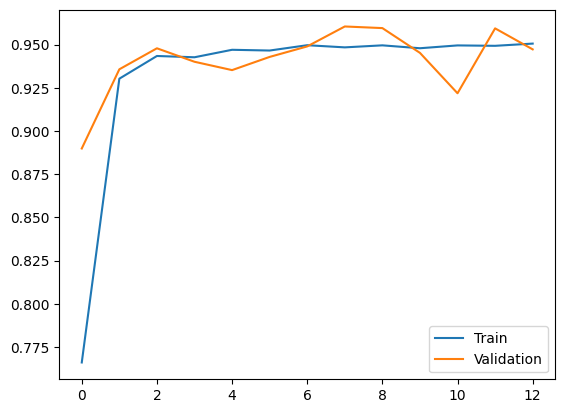

In [164]:
# Visualisasi akurasi training dan validation untuk mengevaluasi performa model

### MULAI CODE ###

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()

### SELESAI CODE ###

In [165]:
# Mengubah hasil prediksi probabilitas menjadi label kelas dan menampilkan evaluasi model (precision, recall, f1-score)

### MULAI CODE ###

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

### SELESAI CODE ###

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      3216
           1       0.97      0.95      0.96      4797

    accuracy                           0.96      8013
   macro avg       0.95      0.96      0.95      8013
weighted avg       0.96      0.96      0.96      8013



# **5. Inference (Prediksi Pada Data Baru)**

In [166]:
### MULAI CODE ###

# Inout Data Baru
data_baru = [[1, 48, 12.5, 90.0]]

data_baru_scaled = scaler.transform(data_baru)

# prediksi probabilitas dan ubah ke label 0 atau 1
pred_prob = model.predict(data_baru_scaled)
pred_label = (pred_prob > 0.5).astype("int32")

# tampilkan probabilitas
print("Probabilitas:", pred_prob[0][0])

# tampilkan hasil akhir
if pred_label[0][0] == 1:
    print("Stunting")
else:
    print("Tidak Stunting")

### SELESAI CODE ###

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Probabilitas: 0.00018662108
Tidak Stunting


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
